# EDA - Delhi AQI Features

This notebook performs EDA on the exact same data that is stored in Hopsworks Feature Store.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import sys
import os

sys.path.append(os.path.abspath(os.path.join('..')))
from feature_pipeline.fetch_data import fetch_historical
from feature_pipeline.engineer_features import engineer_features

df_raw = fetch_historical(days=365)
df = engineer_features(df_raw)
df.head()

2026-06-07 19:58:30,355 - feature_pipeline.fetch_data - INFO - Fetching 365 days in 53 chunks of 7 days each...
2026-06-07 19:58:33,037 - feature_pipeline.fetch_data - INFO - Chunk 1/53 done → 168 records (total: 168)
2026-06-07 19:58:34,778 - feature_pipeline.fetch_data - INFO - Chunk 2/53 done → 168 records (total: 336)
2026-06-07 19:58:36,636 - feature_pipeline.fetch_data - INFO - Chunk 3/53 done → 168 records (total: 504)
2026-06-07 19:58:38,382 - feature_pipeline.fetch_data - INFO - Chunk 4/53 done → 168 records (total: 672)
2026-06-07 19:58:40,159 - feature_pipeline.fetch_data - INFO - Chunk 5/53 done → 168 records (total: 840)
2026-06-07 19:58:42,068 - feature_pipeline.fetch_data - INFO - Chunk 6/53 done → 168 records (total: 1008)
2026-06-07 19:58:43,827 - feature_pipeline.fetch_data - INFO - Chunk 7/53 done → 168 records (total: 1176)
2026-06-07 19:58:45,451 - feature_pipeline.fetch_data - INFO - Chunk 8/53 done → 168 records (total: 1344)
2026-06-07 19:58:47,434 - feature_pip

,city,timestamp,unix_time,aqi,co,no,no2,o3,so2,pm25,pm10,nh3,hour,day,month,aqi_change_rate,rolling_avg_24,pm25_pm10_ratio,aqi_category
0,delhi,2025-06-07 10:00:00,1749290400,4,170.10,0.10,0.98,133.62,2.42,47.68,124.48,12.36,10,5,6,0.0,4.0,0.3830,Poor
1,delhi,2025-06-07 11:00:00,1749294000,4,179.69,0.13,1.56,135.62,2.51,48.68,122.18,13.52,11,5,6,0.0,4.0,0.3984,Poor
2,delhi,2025-06-07 12:00:00,1749297600,4,192.03,0.14,2.48,136.47,2.63,49.71,119.92,14.76,12,5,6,0.0,4.0,0.4145,Poor
3,delhi,2025-06-07 13:00:00,1749301200,4,224.63,0.09,5.40,130.33,2.99,51.64,116.88,17.92,13,5,6,0.0,4.0,0.4418,Poor
4,delhi,2025-06-07 14:00:00,1749304800,4,278.93,0.01,8.97,119.82,3.67,55.07,114.92,22.52,14,5,6,0.0,4.0,0.4792,Poor


In [2]:
print(f"Shape: {df.shape}")
print(f"\nColumns: {list(df.columns)}")
print(f"\nData Types:\n{df.dtypes}")
print(f"\nMissing Values:\n{df.isnull().sum()}")

Shape: (8496, 19)

Columns: ['city', 'timestamp', 'unix_time', 'aqi', 'co', 'no', 'no2', 'o3', 'so2', 'pm25', 'pm10', 'nh3', 'hour', 'day', 'month', 'aqi_change_rate', 'rolling_avg_24', 'pm25_pm10_ratio', 'aqi_category']

Data Types:
city                object
timestamp           object
unix_time            int64
aqi                  int64
co                 float64
no                 float64
no2                float64
o3                 float64
so2                float64
pm25               float64
pm10               float64
nh3                float64
hour                 int32
day                  int32
month                int32
aqi_change_rate    float64
rolling_avg_24     float64
pm25_pm10_ratio    float64
aqi_category        object
dtype: object

Missing Values:
city               0
timestamp          0
unix_time          0
aqi                0
co                 0
no                 0
no2                0
o3                 0
so2                0
pm25               0
pm10        

In [3]:
df.describe().round(2)

,unix_time,aqi,co,no,no2,o3,so2,pm25,pm10,nh3,hour,day,month,aqi_change_rate,rolling_avg_24,pm25_pm10_ratio
count,8.496000e+03,8496.00,8496.00,8496.00,8496.00,8496.00,8496.00,8496.00,8496.00,8496.00,8496.00,8496.00,8496.00,8496.00,8496.00,8496.00
mean,1.764792e+09,3.54,497.23,0.38,11.41,70.91,3.47,66.42,91.32,12.80,11.50,3.01,6.64,-0.00,3.55,0.69
std,9.091855e+06,1.17,295.86,0.97,8.24,39.07,2.76,62.50,69.49,14.49,6.92,1.98,3.43,0.28,1.09,0.18
min,1.749290e+09,1.00,103.01,0.00,0.57,1.16,0.42,0.00,0.00,0.00,0.00,0.00,1.00,-2.00,1.00,0.00
25%,1.756936e+09,3.00,282.19,0.00,4.86,39.62,1.64,23.70,37.88,3.07,5.75,1.00,4.00,0.00,2.67,0.54
50%,1.764581e+09,3.00,433.14,0.04,10.00,63.18,2.77,43.78,74.18,6.98,11.50,3.00,7.00,0.00,3.46,0.72
75%,1.772832e+09,5.00,642.27,0.28,15.99,97.80,4.53,86.78,120.71,16.78,17.25,5.00,10.00,0.00,4.67,0.84
max,1.780823e+09,5.00,2182.55,11.41,47.11,199.04,45.86,406.34,421.46,103.63,23.00,6.00,12.00,1.00,5.00,0.98


In [4]:
print("AQI Distribution:")
print(df['aqi_category'].value_counts())

AQI Distribution:
aqi_category
Very Poor    2540
Moderate     2459
Fair         1710
Poor         1611
Good          176
Name: count, dtype: int64


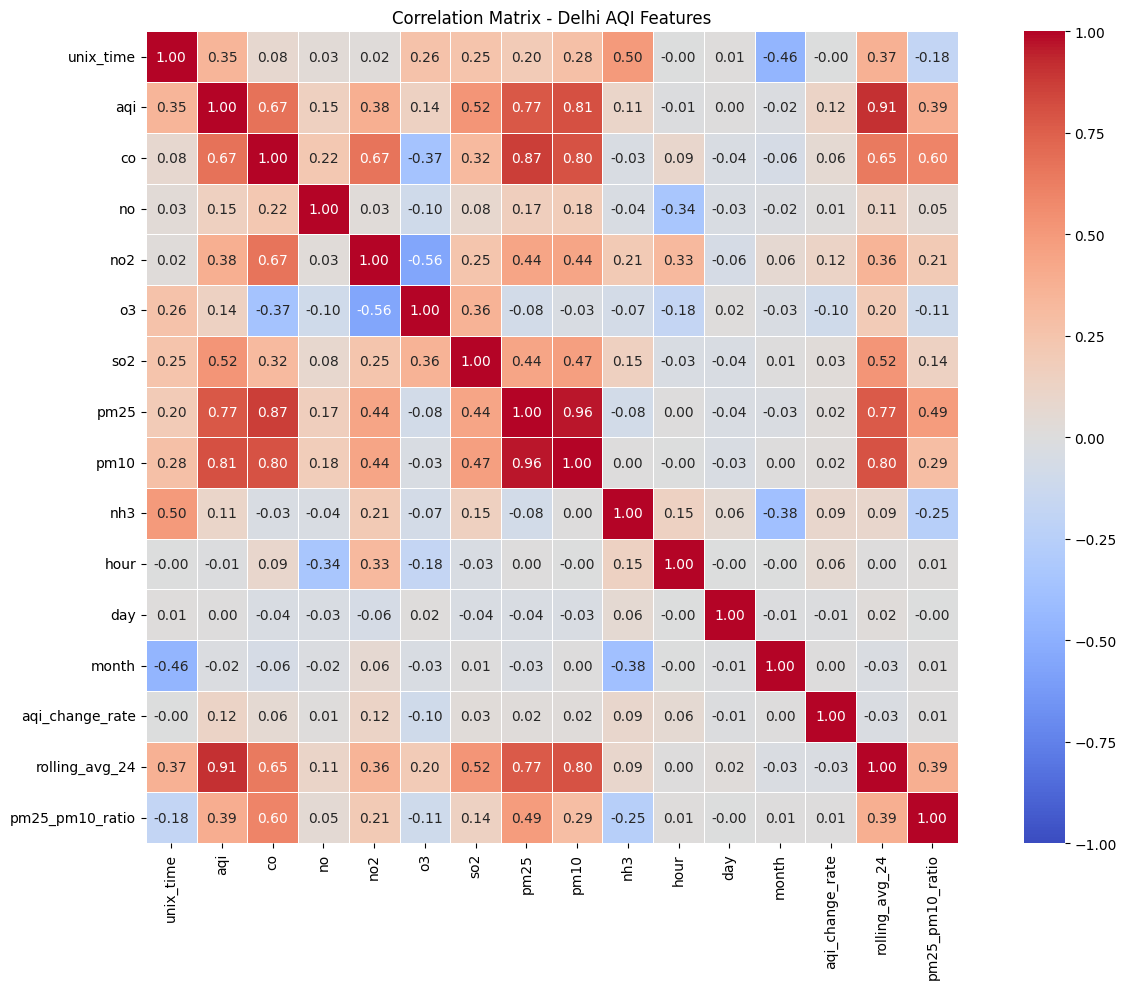

In [5]:
numeric_cols = df.select_dtypes(include=['number']).columns.tolist()
corr = df[numeric_cols].corr()

plt.figure(figsize=(14, 10))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', vmin=-1, vmax=1,
            square=True, linewidths=0.5)
plt.title('Correlation Matrix - Delhi AQI Features')
plt.tight_layout()
plt.show()

In [6]:
aqi_corr = corr['aqi'].drop('aqi').sort_values(ascending=False)

print('Feature Correlation with AQI (sorted):')
print('=' * 50)
for feature, value in aqi_corr.items():
    strength = 'STRONG' if abs(value) > 0.5 else 'MEDIUM' if abs(value) > 0.3 else 'WEAK'
    print(f'  {feature:20s}  {value:+.4f}  [{strength}]')

Feature Correlation with AQI (sorted):
  rolling_avg_24        +0.9117  [STRONG]
  pm10                  +0.8084  [STRONG]
  pm25                  +0.7750  [STRONG]
  co                    +0.6738  [STRONG]
  so2                   +0.5178  [STRONG]
  pm25_pm10_ratio       +0.3911  [MEDIUM]
  no2                   +0.3830  [MEDIUM]
  unix_time             +0.3474  [MEDIUM]
  no                    +0.1511  [WEAK]
  o3                    +0.1411  [WEAK]
  aqi_change_rate       +0.1214  [WEAK]
  nh3                   +0.1093  [WEAK]
  day                   +0.0001  [WEAK]
  hour                  -0.0131  [WEAK]
  month                 -0.0217  [WEAK]


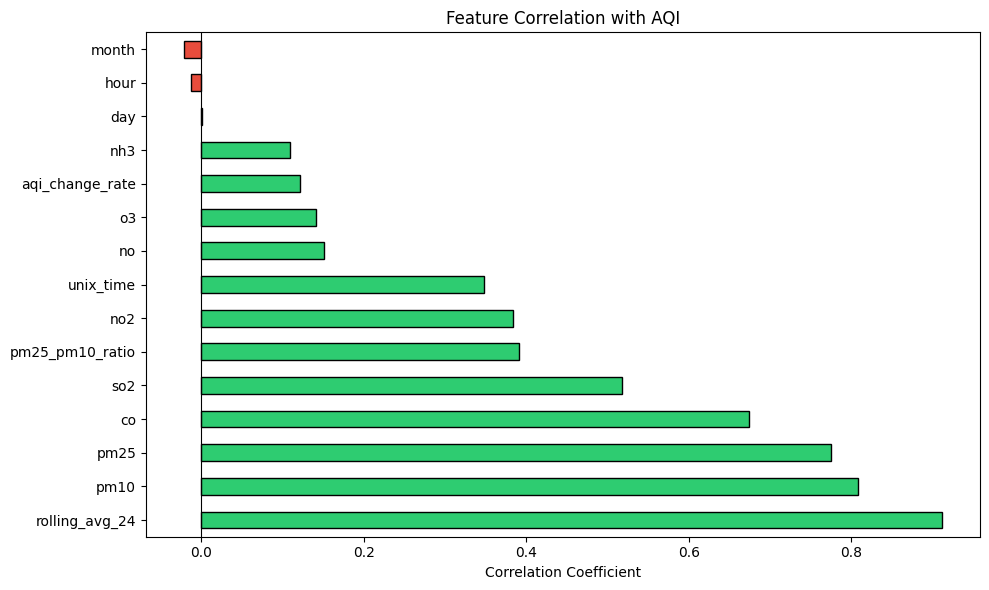

In [7]:
plt.figure(figsize=(10, 6))
colors = ['#e74c3c' if v < 0 else '#2ecc71' for v in aqi_corr]
aqi_corr.plot(kind='barh', color=colors, edgecolor='black')
plt.title('Feature Correlation with AQI')
plt.xlabel('Correlation Coefficient')
plt.axvline(x=0, color='black', linewidth=0.8)
plt.tight_layout()
plt.show()